# Instrument Primer — NIRISS GR150R / F150W

This notebook explains how the NIRISS GR150R grism disperses light onto the detector. It covers the active diffraction orders, their sensitivity, trace geometry, dispersion law, and which source positions contribute to a given image stamp. No forward-operator build is required — all computations use `config.get_trace()` directly.

> **Dependency note:** Trace geometry is provided by the [`grismagic`](https://github.com/your-org/grismagic) package via `spectrex.InstrumentConfig`. The dispersion coefficients come from the `GR150R.F150W.220725.conf` calibration file.

## §0 — Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import spectrex
from spectrex import EigenspectraBasis, InstrumentConfig
from spectrex.instrument import _ORDER_LETTER_TO_INT

# ── Paths ────────────────────────────────────────────────────────────────────
TESTDATA = Path('../testdata')
IMAGE_SHAPE = (500, 20)   # detector stamp used throughout
SOURCE_I, SOURCE_J = 250, 10  # reference source position

# ── Colour palette (consistent across all figures) ───────────────────────────
ORDER_COLOURS = {'A': '#4da6ff', 'B': '#ff9f40', 'C': '#c08cff'}
ORDER_LABELS  = {'A': 'Order A (1st, dispersed)',
                 'B': 'Order B (0th, undispersed)',
                 'C': 'Order C (2nd, dispersed)'}

# ── Load instrument config ────────────────────────────────────────────────────
config = InstrumentConfig.from_files(
    conf_path=TESTDATA / 'Config Files' / 'GR150R.F150W.220725.conf',
    wavelengthrange_path=TESTDATA / 'jwst_niriss_wavelengthrange_0002.asdf',
    sensitivity_dir=TESTDATA / 'SenseConfig' / 'wfss-grism-configuration',
    filter_name='F150W',
    n_wavelengths=150,
)

basis = EigenspectraBasis.from_csv(
    TESTDATA / 'eigenspectra_kurucz.csv',
    config.wavelengths,
)

# Active orders: those with calibrated sensitivity
active_orders = [o for o in config.orders if o in config.sensitivity]

# ── Summary table ────────────────────────────────────────────────────────────
print(f'spectrex {spectrex.__version__}')
print(f'Grism : {config.grism}')
print(f'Filter: {config.filter_name}')
print(f'λ range: {config.wavelengths[0]:.0f} – {config.wavelengths[-1]:.0f} Å  '
      f'({len(config.wavelengths)} samples)')
print()
print(f'{"Order":<8}{"Integer":<10}{"Physical meaning":<28}{"Has sensitivity"}')
print('-' * 60)
meaning = {0: '0th (undispersed)', 1: '1st (dispersed)', 2: '2nd (dispersed)'}
for o in config.orders:
    idx = _ORDER_LETTER_TO_INT.get(o, '?')
    has_sens = 'yes' if o in config.sensitivity else 'no'
    print(f'{o:<8}{str(idx):<10}{meaning.get(idx, "unknown"):<28}{has_sens}')


spectrex 0.2.1.dev18+gc6f5edaa6.d20260506
Grism : GR150R
Filter: F150W
λ range: 12900 – 17100 Å  (150 samples)

Order   Integer   Physical meaning            Has sensitivity
------------------------------------------------------------
A       1         1st (dispersed)             yes
B       0         0th (undispersed)           yes
C       2         2nd (dispersed)             yes
D       ?         unknown                     no
E       ?         unknown                     no


## §1 — Diffraction orders & sensitivity

The GR150R grism produces several diffraction orders simultaneously. Three carry calibrated flux sensitivity: **order A** (1st order, dispersed spectrum), **order B** (0th order — the undispersed image of the source), and **order C** (2nd order, further dispersed). Orders D and E exist geometrically but have no measured sensitivity and are excluded from the forward model.

The plot below shows how much flux each order captures as a function of wavelength. The *total flux fraction* (area under each curve) is roughly equal across A, B, and C — meaning order B carries ~12 % of the total source flux, concentrated into just 4–5 detector pixels instead of the ~91 pixels used by order A. This concentration is the physical origin of the isolated bright spots visible in multi-source dispersed images.

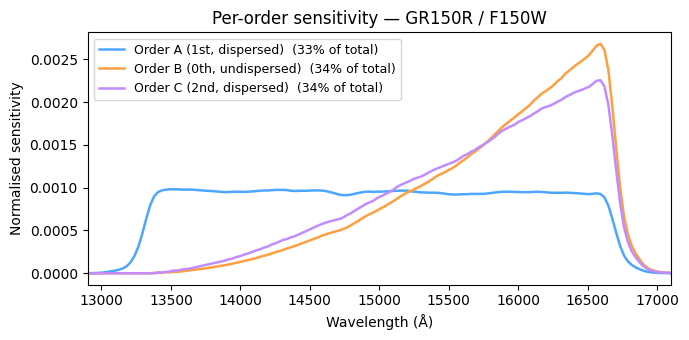

In [2]:
fig, ax = plt.subplots(figsize=(7, 3.5))

for order in active_orders:
    sens = config.sensitivity[order]
    total_frac = sens.sum() / sum(config.sensitivity[o].sum() for o in active_orders)
    ax.plot(
        config.wavelengths, sens,
        color=ORDER_COLOURS[order],
        label=f'{ORDER_LABELS[order]}  ({100*total_frac:.0f}% of total)',
        lw=1.8,
    )

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Normalised sensitivity')
ax.set_title('Per-order sensitivity — GR150R / F150W')
ax.legend(fontsize=9)
ax.set_xlim(config.wavelengths[0], config.wavelengths[-1])
fig.tight_layout()
plt.show()


## §2 — Trace geometry

For a source at detector position $(i, j)$, each diffraction order maps the source light onto a different region of the detector. For GR150R the dispersion direction is along **detector rows** (the long axis). The column displacement is small (sub-pixel to ~2 px) and nearly wavelength-independent.

The figure below shows a 500 × 20 pixel stamp. The white dot marks the reference source at row 250, column 10. Coloured boxes show where each order's trace lands; the table summarises the offsets.

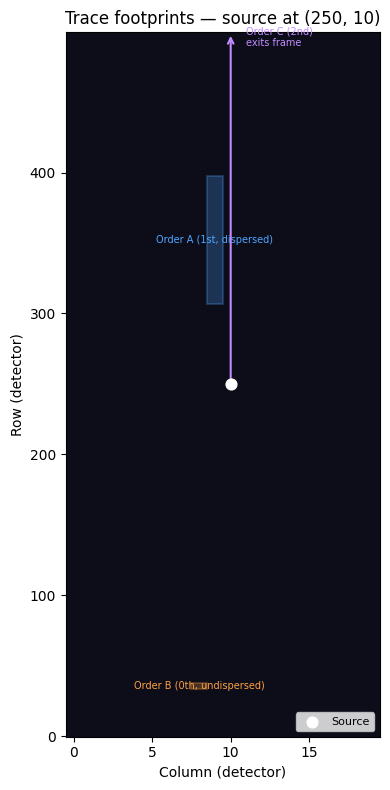

Source position: row=250, col=10
Order   Integer   Row offset range        Col offset    Unique pixels
----------------------------------------------------------------------
A       1         +57 to +147             -1.15 px      91
B       0         +-216 to +-213          -2.28 px      4
C       2         out of frame            -0.16 px      0


In [3]:
n_rows, n_cols = IMAGE_SHAPE

# Compute trace footprints for the reference source
footprints = {}
for order in active_orders:
    x_trace, y_trace = config.get_trace(float(SOURCE_I), float(SOURCE_J), order=order)
    x_pix = np.round(x_trace).astype(int)
    y_pix = np.round(y_trace).astype(int)
    mask = (x_pix >= 0) & (x_pix < n_rows) & (y_pix >= 0) & (y_pix < n_cols)
    footprints[order] = dict(
        x_trace=x_trace, y_trace=y_trace,
        x_pix=x_pix, y_pix=y_pix, mask=mask,
        row_offset_min=float(x_trace[0]  - SOURCE_I),
        row_offset_max=float(x_trace[-1] - SOURCE_I),
        col_offset=float(np.mean(y_trace) - SOURCE_J),
        n_valid=int(mask.sum()),
        n_unique=len(set(zip(x_pix[mask], y_pix[mask]))) if mask.any() else 0,
    )

# ── Figure: annotated stamp ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4, 8))
ax.set_facecolor('#0d0d1a')
ax.set_xlim(-0.5, n_cols - 0.5)
ax.set_ylim(-0.5, n_rows - 0.5)
ax.set_xlabel('Column (detector)')
ax.set_ylabel('Row (detector)')
ax.set_title(f'Trace footprints — source at ({SOURCE_I}, {SOURCE_J})')

# Source position
ax.scatter([SOURCE_J], [SOURCE_I], color='white', s=60, zorder=5, label='Source')

# Order A and B: draw rectangles over actual pixel footprint
for order in ['A', 'B']:
    fp = footprints[order]
    if fp['n_valid'] == 0:
        continue
    col = ORDER_COLOURS[order]
    xp = fp['x_pix'][fp['mask']]
    yp = fp['y_pix'][fp['mask']]
    row_lo, row_hi = xp.min() - 0.5, xp.max() + 0.5
    col_lo, col_hi = yp.min() - 0.5, yp.max() + 0.5
    from matplotlib.patches import Rectangle
    rect = Rectangle(
        (col_lo, row_lo), col_hi - col_lo, row_hi - row_lo,
        linewidth=1.5, edgecolor=col, facecolor=col, alpha=0.25,
    )
    ax.add_patch(rect)
    ax.annotate(
        ORDER_LABELS[order],
        xy=((col_lo + col_hi) / 2, (row_lo + row_hi) / 2),
        fontsize=7, color=col, ha='center', va='center',
    )

# Order C: arrow pointing off top
ax.annotate(
    '', xy=(SOURCE_J, n_rows - 1), xytext=(SOURCE_J, SOURCE_I),
    arrowprops=dict(arrowstyle='->', color=ORDER_COLOURS['C'], lw=1.5),
)
ax.text(
    SOURCE_J + 1, n_rows - 10,
    'Order C (2nd)\nexits frame',
    color=ORDER_COLOURS['C'], fontsize=7,
)

ax.legend(loc='lower right', fontsize=8)
fig.tight_layout()
plt.show()

# ── Summary table ────────────────────────────────────────────────────────────
print(f'Source position: row={SOURCE_I}, col={SOURCE_J}')
print(f'{"Order":<8}{"Integer":<10}{"Row offset range":<24}{"Col offset":<14}{"Unique pixels"}')
print('-' * 70)
for order in active_orders:
    fp = footprints[order]
    idx = _ORDER_LETTER_TO_INT[order]
    if fp['n_valid'] > 0:
        rng_str = f"+{fp['row_offset_min']:.0f} to +{fp['row_offset_max']:.0f}"
    else:
        rng_str = 'out of frame'
    print(f"{order:<8}{str(idx):<10}{rng_str:<24}{fp['col_offset']:+.2f} px{'':<6}{fp['n_unique']}")


## §3 — Dispersion solution

The row offset is not constant — it depends on wavelength. This wavelength-to-row-offset mapping is called the *dispersion solution*. For order A the offset increases from ~+57 px (blue, 12 900 Å) to ~+147 px (red, 17 100 Å), spreading the spectrum across ~90 detector rows. Order C disperses even further (+324 to +501 rows) and exits the 500-row stamp for all but the bluest sources. Order B's near-zero spread (~3.5 px total) confirms it is the undispersed (0th) order: all wavelengths land at nearly the same detector row, creating the compact bright spot seen in §4.

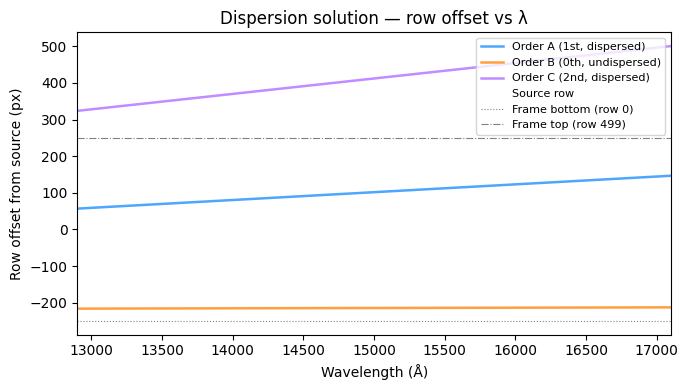

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))

for order in active_orders:
    x_trace, _ = config.get_trace(float(SOURCE_I), float(SOURCE_J), order=order)
    row_offsets = x_trace - SOURCE_I
    ax.plot(
        config.wavelengths, row_offsets,
        color=ORDER_COLOURS[order],
        label=ORDER_LABELS[order],
        lw=1.8,
    )

n_rows = IMAGE_SHAPE[0]
# Frame boundaries for the reference source
ax.axhline(0, color='white', lw=0.6, ls='--', alpha=0.4, label='Source row')
ax.axhline(-SOURCE_I, color='grey', lw=0.8, ls=':', label='Frame bottom (row 0)')
ax.axhline(n_rows - 1 - SOURCE_I, color='grey', lw=0.8, ls='-.',
           label=f'Frame top (row {n_rows-1})')
ax.fill_between(
    config.wavelengths,
    -SOURCE_I, n_rows - 1 - SOURCE_I,
    alpha=0.05, color='white',
)

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Row offset from source (px)')
ax.set_title('Dispersion solution — row offset vs λ')
ax.legend(fontsize=8)
ax.set_xlim(config.wavelengths[0], config.wavelengths[-1])
fig.tight_layout()
plt.show()


## §4 — Single-source dispersed image

Placing a single point source at $(250, 10)$ with a flat stellar spectrum illustrates what each order contributes to the detector. The total image (leftmost panel) is the sum of all order contributions. In a dense-field simulation with ~1 000 sources, the compact order-B spot is ~19× brighter per pixel than the dispersed order-A streak from the same source — this is why individual bright pixels appear in the multi-source dispersed image.

The computation below builds per-order images directly from `get_trace()` without constructing the full forward operator matrix.

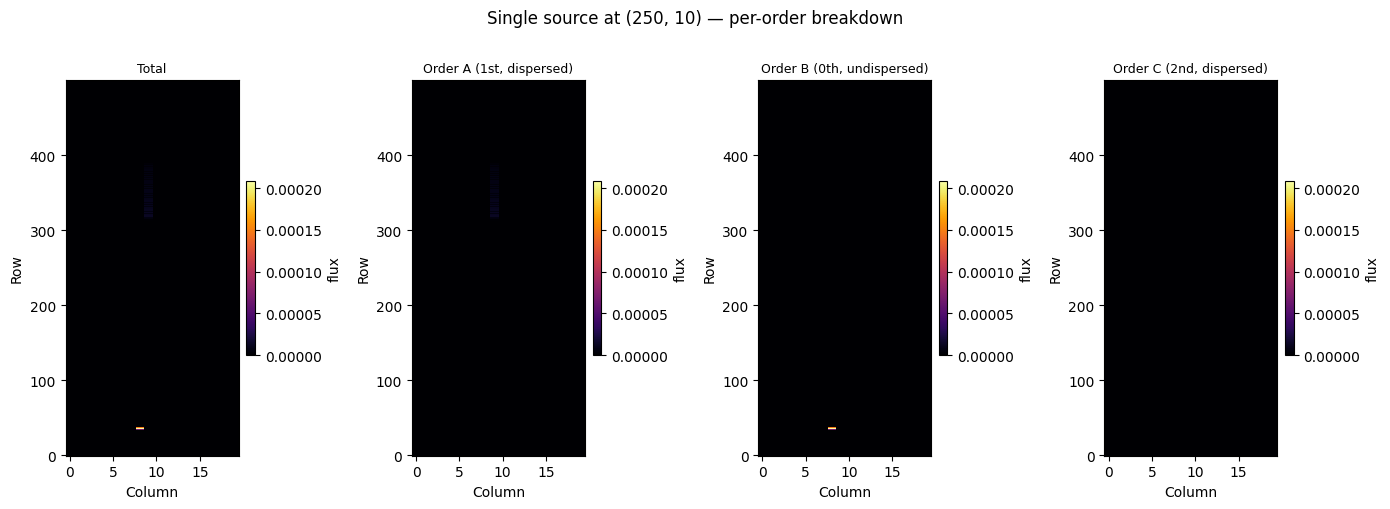

Order A: total flux = 0.0005 over 91 pixels
Order B: total flux = 0.0004 over 4 pixels
Order B is 18.3× brighter per pixel than order A


In [5]:
n_rows, n_cols = IMAGE_SHAPE

# Source spectrum: negate first PCA component → all-positive stellar template
a_k = np.zeros(basis.n_components)
a_k[0] = -1.0
assert np.all(basis.reconstruct(a_k) >= 0), 'Spectrum must be non-negative'

# Build per-order dispersed images
order_images = {}
for order in active_orders:
    img = np.zeros((n_rows, n_cols))
    sens = config.sensitivity[order]
    x_trace, y_trace = config.get_trace(
        float(SOURCE_I), float(SOURCE_J), order=order
    )
    x_pix = np.round(x_trace).astype(int)
    y_pix = np.round(y_trace).astype(int)
    mask = (
        (x_pix >= 0) & (x_pix < n_rows)
        & (y_pix >= 0) & (y_pix < n_cols)
    )
    if mask.any():
        # flux_lam[i] = sensitivity-weighted reconstructed flux at wavelength mask[i]
        flux_lam = (basis.components[mask, :] @ a_k) * sens[mask]  # (n_valid,)
        np.add.at(img, (x_pix[mask], y_pix[mask]), flux_lam)
    order_images[order] = img

total_image = sum(order_images.values())

# ── Figure ───────────────────────────────────────────────────────────────────
panels = [('Total', total_image)] + [(ORDER_LABELS[o], order_images[o]) for o in active_orders]
vmax = total_image.max()
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
kw = dict(origin='lower', aspect='auto', interpolation='nearest',
          cmap='inferno', vmin=0, vmax=vmax)

for ax, (title, img) in zip(axes, panels):
    im = ax.imshow(img, **kw)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='flux')

fig.suptitle(
    f'Single source at ({SOURCE_I}, {SOURCE_J}) — per-order breakdown',
    y=1.01
)
fig.tight_layout()
plt.show()

# Per-pixel brightness ratio: order B vs order A
n_unique_A = len(set(zip(
    *np.where(order_images['A'] > 0)
)))
n_unique_B = len(set(zip(
    *np.where(order_images['B'] > 0)
)))
flux_A = order_images['A'][order_images['A'] > 0].sum()
flux_B = order_images['B'][order_images['B'] > 0].sum()
ratio = (flux_B / n_unique_B) / (flux_A / n_unique_A)
print(f'Order A: total flux = {flux_A:.4f} over {n_unique_A} pixels')
print(f'Order B: total flux = {flux_B:.4f} over {n_unique_B} pixels')
print(f'Order B is {ratio:.1f}× brighter per pixel than order A')
